# Evaluación del modelo base

En este notebook se evalúa el desempeño del modelo base de red neuronal convolucional sobre el conjunto de prueba.  
Se calculan métricas de clasificación y se generan visualizaciones para interpretar el comportamiento del modelo.

## Importación de librerías
Se cargan las librerías necesarias para reconstruir el dataset, definir el modelo y evaluar su desempeño.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## Verificación del dispositivo
Se identifica si el modelo se ejecutará en CPU o GPU.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cpu


## Reconstrucción de variables base
Se redefine la ruta del dataset y las clases para que el notebook pueda ejecutarse de forma independiente.

In [4]:
ruta_dataset = Path("C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/data/raw")

clases = sorted([carpeta.name for carpeta in ruta_dataset.iterdir() if carpeta.is_dir()])
clase_a_indice = {clase: idx for idx, clase in enumerate(clases)}
indice_a_clase = {idx: clase for clase, idx in clase_a_indice.items()}

print("Clases encontradas:")
print(clases)

Clases encontradas:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Tabla base del dataset
Se genera una tabla con la ruta de cada imagen y su clase correspondiente.

In [5]:
registros_dataset = []

for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    for img_path in imagenes:
        registros_dataset.append({
            "ruta": str(img_path),
            "clase": clase
        })

df_dataset = pd.DataFrame(registros_dataset)
df_dataset["label"] = df_dataset["clase"].map(clase_a_indice)

df_dataset.head()

,ruta,clase,label
0,C:\Users\adria\OneDrive\Documentos\ESCOM\6 SEM...,angry,0
1,C:\Users\adria\OneDrive\Documentos\ESCOM\6 SEM...,angry,0
2,C:\Users\adria\OneDrive\Documentos\ESCOM\6 SEM...,angry,0
3,C:\Users\adria\OneDrive\Documentos\ESCOM\6 SEM...,angry,0
4,C:\Users\adria\OneDrive\Documentos\ESCOM\6 SEM...,angry,0


## Partición del dataset
Se reconstruyen los subconjuntos de entrenamiento, validación y prueba con la misma partición usada en el entrenamiento.

In [6]:
df_train, df_temp = train_test_split(
    df_dataset,
    test_size=0.30,
    stratify=df_dataset["clase"],
    random_state=42
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["clase"],
    random_state=42
)

print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Train: (34845, 3)
Validation: (7467, 3)
Test: (7467, 3)


## Transformaciones para evaluación
En esta etapa solo se aplica el preprocesamiento base, sin aumento de datos.

In [7]:
transform_test = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

## Dataset personalizado
Se define la clase para cargar las imágenes y sus etiquetas desde las rutas almacenadas.

In [8]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "ruta"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## Conjunto de prueba
Se construye el dataset y DataLoader del conjunto de prueba.

In [9]:
test_dataset = EmotionDataset(df_test, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test loader creado correctamente")

Test loader creado correctamente


## Arquitectura del modelo base
Se redefine la CNN base para poder cargar los pesos entrenados.

In [10]:
class CNNBase(nn.Module):
    def __init__(self, num_classes=7):
        super(CNNBase, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Carga del modelo entrenado
Se cargan los pesos guardados del modelo base entrenado en el notebook anterior.

In [12]:
model = CNNBase(num_classes=len(clases)).to(device)
model.load_state_dict(torch.load("C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/models/cnn_base_emociones.pth", map_location=device))
model.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


## Predicciones sobre el conjunto de prueba
Se generan las predicciones del modelo sobre imágenes no vistas durante el entrenamiento.

In [13]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

## Exactitud en prueba
Se calcula la precisión global del modelo sobre el conjunto de prueba.

In [14]:
acc_test = accuracy_score(y_true, y_pred)
print(f"Accuracy en test: {acc_test:.4f}")

Accuracy en test: 0.6130


## Matriz de confusión
Se visualiza la matriz de confusión para identificar qué emociones se clasifican correctamente y cuáles presentan mayor confusión.

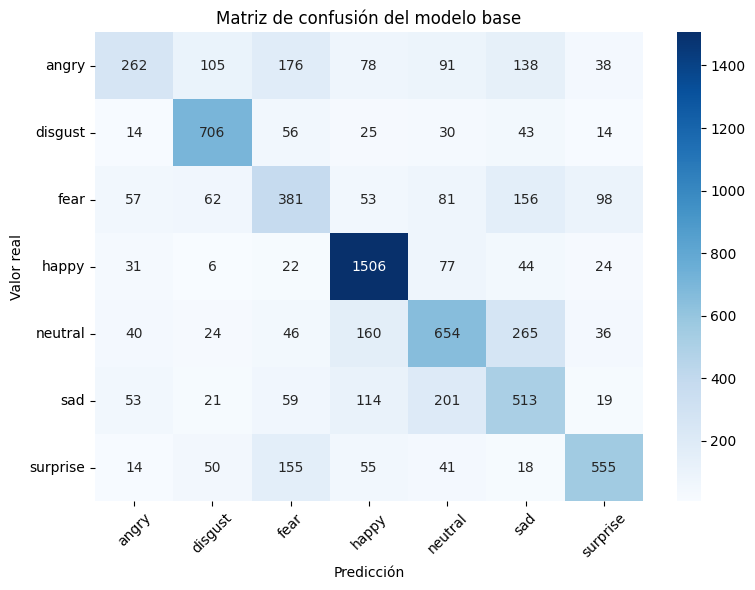

In [15]:
matriz_conf = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_conf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión del modelo base")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Reporte de clasificación
Se calculan precisión, recall y F1-score por clase.

In [16]:
reporte = classification_report(y_true, y_pred, target_names=clases)
print(reporte)

              precision    recall  f1-score   support

       angry       0.56      0.30      0.39       888
     disgust       0.72      0.80      0.76       888
        fear       0.43      0.43      0.43       888
       happy       0.76      0.88      0.81      1710
     neutral       0.56      0.53      0.55      1225
         sad       0.44      0.52      0.48       980
    surprise       0.71      0.62      0.66       888

    accuracy                           0.61      7467
   macro avg       0.59      0.58      0.58      7467
weighted avg       0.61      0.61      0.60      7467



## Ejemplos de predicción
Se muestran algunas imágenes del conjunto de prueba junto con su clase real y la clase predicha.

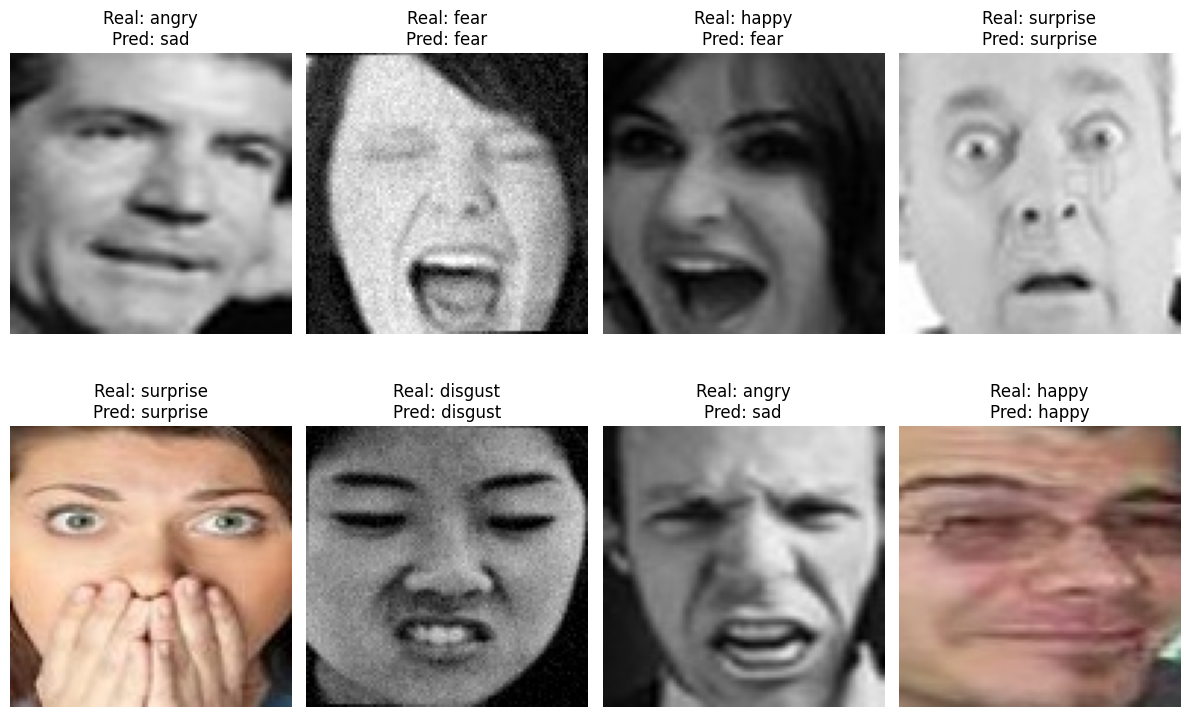

In [17]:
imagenes_test, etiquetas_test = next(iter(test_loader))

with torch.no_grad():
    outputs = model(imagenes_test.to(device))
    _, preds_test = torch.max(outputs, 1)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = imagenes_test[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    real = indice_a_clase[etiquetas_test[i].item()]
    pred = indice_a_clase[preds_test[i].item()]
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusión 

En esta etapa se evaluó el modelo base de red neuronal convolucional sobre el conjunto de prueba con el fin de analizar su capacidad de generalización. Los resultados muestran una exactitud global de 0.61, lo que confirma que el modelo logra identificar patrones relevantes en las imágenes faciales, aunque todavía presenta limitaciones para diferenciar emociones con expresiones similares. Las clases con mejor desempeño fueron happy, disgust y surprise, mientras que angry, fear y sad registraron mayores niveles de confusión. La matriz de confusión y los ejemplos de predicción permitieron observar que los errores del modelo se concentran principalmente entre categorías visualmente cercanas, lo cual es esperable en un modelo base. En conjunto, esta evaluación muestra que la CNN inicial constituye un punto de partida funcional, pero también evidencia la necesidad de mejoras posteriores, como ajuste de hiperparámetros, mayor número de épocas, técnicas para manejar el desbalance de clases o el uso de modelos más avanzados como transferencia de aprendizaje.